## Physics 3. Laboratory experiment #3. Microwaves.

Dr. Ernst Uzhansky, 2024, v0.1.1

Outline of the lab:

#### Day 1

1. Lattice as a polarizer
2. Waveguide (galbo) features

#### Day 2

3. Michelson interferometer
4. Fabry-Peroh interferometer
5. Lloyd interferometer

## Import libraries

In [27]:
import matplotlib.pyplot as plt  # for plotting figures and setting their properties
import numpy as np  # math functions
import scipy  # scientific functions

# from prettytable import PrettyTable 		# display data in visually table format
from scipy.stats import linregress  # contains linregress (for linear regression)
from sklearn.metrics import r2_score  # import function that calculates R^2 score

### Part 1. Lattice as a polarizer

Place the detector in front of the transmitter, measure and plot the radiation intensity received by the detector for the following two cases:
1. Without a lattice between the transmitter and the detector
2. With a grating between the transmitter and the detector

Keep in mind that lettice acts as a filter and, technally, it can be considered as a source of polarized microwaves. That is why you have $cos^{4}$ dependence, namely $cos^{2}$ dependence from the source to the lettice, and one more $cos^{2}$ dendence from the lettice to the receiver.

Mind that every graduation mark on the back of the source and receiver correspond to 5 degrees.

**Figure 1.** Intensity vs $cos^2(\theta)$. Case without a polarizer.


[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170. 180.]
Linear fit: slope=0.367194, intercept=0.099024, R^2=0.898288


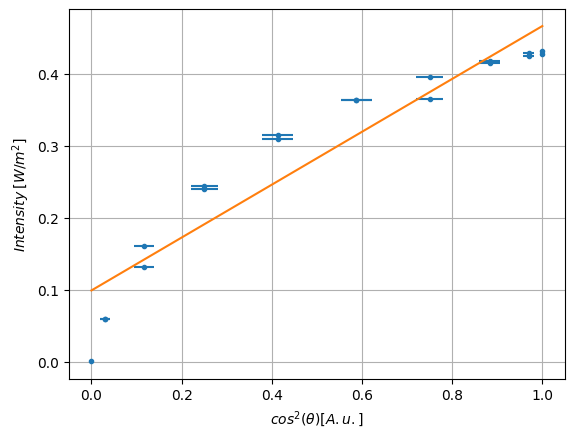

In [28]:
angleoffset = 0
angles2 = np.linspace(0, 180, 19) + angleoffset  # +-4, deg
print(angles2)
intensity2 = (
    np.array(
        (
            431,
            429,
            418,
            396,
            364,
            309,
            244,
            132,
            59,
            0.6,
            59.3,
            161,
            240.5,
            315,
            363,
            365,
            415,
            424,
            428,
        )
    )
    / 1000
)  # ±1e-3, Volt

rad_angles2 = np.deg2rad(angles2)
data2 = np.cos(rad_angles2) ** 2
plt.style.use("default")
delta_theta_deg = 2  # measurement uncertainty in degrees (adjust if different)
delta_theta_rad = np.deg2rad(delta_theta_deg)
# propagate angle uncertainty to x (cos^2) using derivative d(cos^2)/dθ = -2 cos(θ) sin(θ)
xerr = np.abs(-2 * np.cos(rad_angles2) * np.sin(rad_angles2)) * delta_theta_rad
yerr = np.full_like(intensity2, 1e-3)
plt.figure()
plt.grid()
plt.errorbar(x=data2, y=intensity2, xerr=xerr, yerr=yerr, fmt=".")
# Linear regression for intensity2 vs data2 and print R^2
slope, intercept, r_value, p_value, stderr = linregress(data2, intensity2)
pred = slope * data2 + intercept
r2 = r_value**2
print(f"Linear fit: slope={slope:.6f}, intercept={intercept:.6f}, R^2={r2:.6f}")
# plot fit line
x_fit = np.linspace(data2.min(), data2.max(), 100)
plt.plot(x_fit, slope * x_fit + intercept, "-", label=f"fit $R^2$={r2:.3f}")
plt.xlabel("$cos^2(\\theta) [A.u.]$")
plt.ylabel("$Intensity_ [W/m^2]$");

**Figure 2.** Intensity vs $sin^4(\theta)$. Case with a polarizer between the source and the receiver.


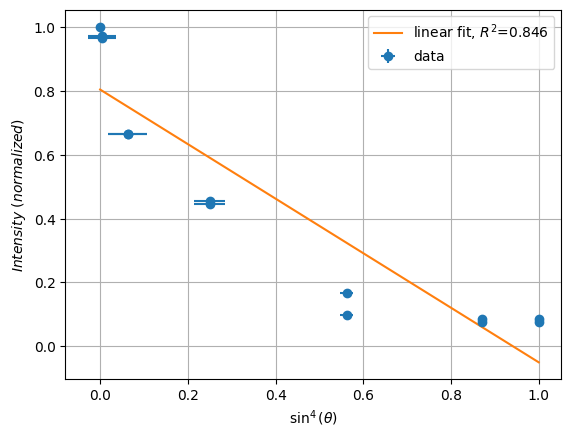

In [29]:
angles = np.linspace(0, 180, 13)  # +-2, deg
angle_err = 2  # degrees
intensity = (
    np.array((35, 35, 69, 185, 275, 400, 414, 403, 275, 189, 41, 31, 31)) / 1000
)  # ±1e-3, Volt
intensity_err = 1e-3
intensity_err_raw = 1e-3  # measurement uncertainty in Volts
max_intensity = intensity.max()
intensity_norm = intensity / max_intensity
intensity_err = intensity_err_raw / max_intensity
intensity /= max_intensity
# intensity = np.power(voltage, 2) # Volts
data = np.power(np.cos(angles * np.pi / 180), 4)

rad = np.deg2rad(angles)
plt.style.use("default")

data = np.cos(rad) ** 4

# propagate angle uncertainty to x (data) using derivative d(cos^4)/dθ = -4 cos^3(θ) sin(θ) * dθ (radians)
xerr = np.abs(4 * np.sin(rad) ** 3 * np.cos(rad)) * np.deg2rad(angle_err)

# linear regression and R^2
slope, intercept, r_value, p_value, stderr = linregress(data, intensity_norm)
r2 = r_value**2
x_fit = np.linspace(data.min(), data.max(), 200)
y_fit = slope * x_fit + intercept

plt.figure()
plt.grid()
plt.errorbar(data, intensity_norm, xerr=xerr, yerr=intensity_err, fmt="o", label="data")
plt.plot(x_fit, y_fit, "-", label=f"linear fit, $R^2$={r2:.3f}")
plt.xlabel("$\\sin^4(\\theta)$")
plt.ylabel("$Intensity\\ (normalized)$")
plt.legend()

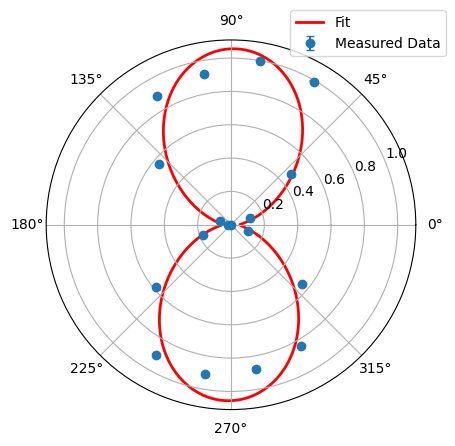

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Data Setup
d = 2.76
q_deg = np.array(
    [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340]
)
q_rad = np.radians(q_deg)

# Your data
intensity_linear = np.array(
    [
        0.24,
        25,
        99,
        207,
        209,
        192,
        186,
        118,
        15,
        3.3,
        37,
        122,
        189,
        190,
        184,
        176,
        116,
        23,
    ]
)

# 2. Normalization and Error
I_max = intensity_linear.max()
I_norm = intensity_linear / I_max

# Error: Assuming 0.1 error in the original units (based on your comment ±1e-1)
# Propagated error for normalized plot:
error_val = 0.1
I_error_norm = np.full_like(I_norm, error_val / I_max)


# 3. Theoretical Model: Malus's Law (The "Shape of 8")
def malus_model(theta, phase, offset):
    # I = I_0 * cos^2(theta - phase) + offset
    # Since we normalized, I_0 is effectively 1, but the fit handles slight variations
    return np.cos(theta - phase) ** 2 + offset


# Fit the model to find the best phase angle
# Initial guess: max at ~80 degrees (approx 1.4 rad) based on data
popt, _ = curve_fit(malus_model, q_rad, I_norm, p0=[1.4, 0])

# Generate smooth curve for plotting
theta_smooth = np.linspace(0, 2 * np.pi, 500)
I_smooth = malus_model(theta_smooth, *popt)
I_compare = malus_model(q_rad, *popt)

r2 = r2_score(I_norm, I_compare)
# 4. Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection="polar")

# Plot Data with Error Bars
# Note: 'zorder' ensures data sits on top of the line
ax.errorbar(
    q_rad,
    I_norm,
    yerr=I_error_norm,
    fmt="o",
    capsize=3,
    label="Measured Data",
    zorder=2,
)

# Plot Theoretical Curve
ax.plot(theta_smooth, I_smooth, "r-", linewidth=2, label=r"Fit", zorder=1)

# Formatting
ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1))

plt.savefig("first_polar.svg")

plt.show()

### Part 2. Waveguide (galbo) features

Assemble the waveguide device and make measurements according to the instruction list.

**Figure 3.** Perpendicular case. Intensity vs width of the waveguide.

Adjacent fit: slope=10.937951, intercept=-0.048427, R^2=0.325999


Text(0, 0.5, 'Intensity [W/m^2]')

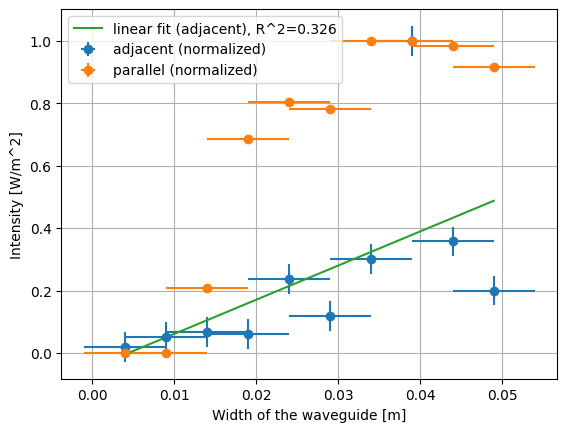

In [31]:
# Perpendicular case
d = (np.array([5, 4.5, 4, 3.5, 3, 2.5, 2, 1.5, 1, 0.5]) - 0.1) * 1e-2  # ±0.5e-3, metres
d_err = 5e-3
intensity_adjacent_raw = (
    np.array([4.2, 7.5, 21, 6.3, 2.5, 5, 1.3, 1.4, 1.1, 0.4]) * 1e-3
)  # ±1e-3, Volts // perpendicular

intensity_parallel_raw = np.array(
    [468, 503, 511, 511, 400, 410, 350, 106, 0.14, 0.1]
)  # ±1e-3, Volts
int_err_raw = 1e-3  # 1 mV

# normalize each series by its max (as in original)
intensity_adjacent = intensity_adjacent_raw / intensity_adjacent_raw.max()
intensity_parallel = intensity_parallel_raw / intensity_parallel_raw.max()
plt.style.use("default")

# propagated measurement uncertainty after normalization
intensity_err_adj = int_err_raw / intensity_adjacent_raw.max()
intensity_err_par = int_err_raw / intensity_parallel_raw.max()

plt.grid()
plt.errorbar(
    d,
    intensity_adjacent,
    xerr=d_err,
    yerr=intensity_err_adj,
    fmt="o",
    label="adjacent (normalized)",
)
plt.errorbar(
    d,
    intensity_parallel,
    xerr=d_err,
    yerr=intensity_err_par,
    fmt="o",
    label="parallel (normalized)",
)

# Linear regression for parallel case (normalized)
slope, intercept, r_value, p_value, stderr = linregress(d, intensity_adjacent)
r2 = r_value**2
x_fit = np.linspace(d.min(), d.max(), 100)
plt.plot(
    x_fit, slope * x_fit + intercept, "-", label=f"linear fit (adjacent), R^2={r2:.3f}"
)

plt.xlabel("Width of the waveguide [m]")
plt.ylabel("Intensity [W/m^2]")
plt.legend()
print(f"Adjacent fit: slope={slope:.6f}, intercept={intercept:.6f}, R^2={r2:.6f}")
plt.xlabel("Width of the waveguide [m]")
plt.ylabel("Intensity [W/m^2]")

## Polar graphs

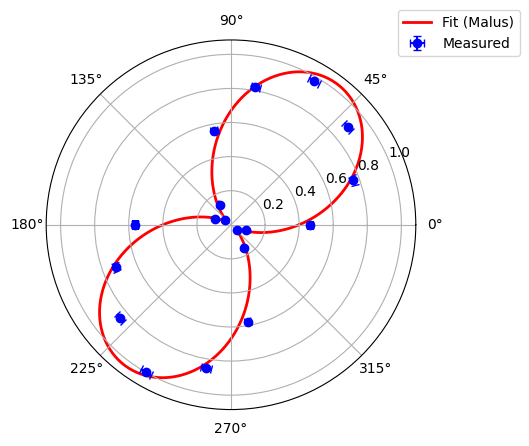

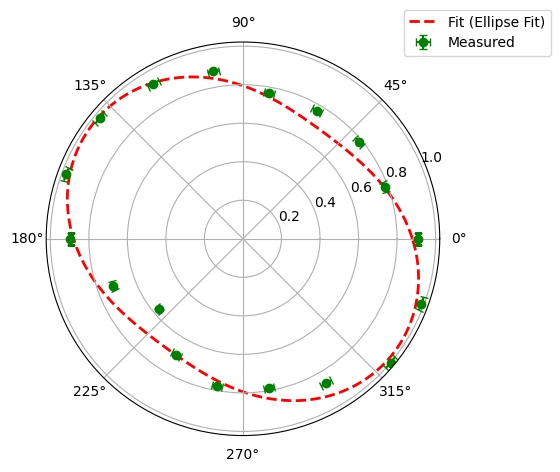

Circular Data Stats -> Average: 361.611, Std: 49.341
R^2 (Linear Fit): 0.9633
R^2 (Circular Fit): 0.7951
Axial Ratio (I_max/I_min): 1.416 (1.0 = Circle, >1.0 = Ellipse)


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# --- 1. Data Entry ---
q_deg = np.array(
    [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340]
)
q_rad = np.radians(q_deg)

linear_intensities = np.array(
    [155, 255, 299, 326, 275, 187, 45, 15, 33, 188, 240, 284, 334, 285, 193, 52, 16, 32]
)
circular_intensities = np.array(
    [
        393,
        338,
        339,
        332,
        332,
        381,
        402,
        420,
        422,
        387,
        309,
        246,
        300,
        336,
        340,
        374,
        432,
        426,
    ]
)

# Errors
theta_err_deg = 2.0
theta_err_rad = np.radians(theta_err_deg)
intensity_err_mv = 5.0


# --- 2. Helper Functions ---
def normalize_and_err(data, abs_err):
    max_val = np.max(data)
    norm = data / max_val
    # Scale error: err_norm = err_abs / max_val
    err_norm = np.full_like(data, abs_err / max_val)
    return norm, err_norm, max_val


def malus_law(theta, phase, offset):
    return np.cos(theta - phase) ** 2 + offset


def ellipse_model(theta, I_maj, I_min, angle_offset):
    return (
        I_maj * np.cos(theta - angle_offset) ** 2
        + I_min * np.sin(theta - angle_offset) ** 2
    )


# --- 3. Process Data (The Missing Step) ---
# This actually creates the variables needed for fitting
norm_lin, err_lin, max_lin = normalize_and_err(linear_intensities, intensity_err_mv)
norm_circ, err_circ, max_circ = normalize_and_err(
    circular_intensities, intensity_err_mv
)

# --- 4. Fitting ---
# Fit Linear
popt_lin, _ = curve_fit(malus_law, q_rad, norm_lin, p0=[1.0, 0])

# Fit Circular (Guessing initial parameters helps convergence)
popt_circ, _ = curve_fit(ellipse_model, q_rad, norm_circ, p0=[1.0, 0.5, 0])

# Generate smooth curves
theta_smooth = np.linspace(0, 2 * np.pi, 500)
curve_lin = malus_law(theta_smooth, *popt_lin)
curve_circ = ellipse_model(theta_smooth, *popt_circ)

# --- 5. Plotting ---
fig = plt.figure()

y_pred_lin = malus_law(q_rad, *popt_lin)
y_pred_circ = ellipse_model(q_rad, *popt_circ)

r2_lin = r2_score(norm_lin, y_pred_lin)
r2_circ = r2_score(norm_circ, y_pred_circ)

# Graph 1: Linear
ax1 = fig.add_subplot(projection="polar")
ax1.errorbar(
    q_rad,
    norm_lin,
    xerr=theta_err_rad,
    yerr=err_lin,
    fmt="o",
    capsize=3,
    label="Measured",
    color="blue",
    zorder=2,
)
ax1.plot(
    theta_smooth,
    curve_lin,
    "r-",
    linewidth=2,
    label="fit (Malus), R^2 = " + str(np.round(r2_circ * 1e3) * 1e-3),
    zorder=1,
)
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.savefig("linear_polarization.svg")

fig = plt.figure()
# Graph 2: Circular
ax2 = fig.add_subplot(projection="polar")
ax2.errorbar(
    q_rad,
    norm_circ,
    xerr=theta_err_rad,
    yerr=err_circ,
    fmt="o",
    capsize=3,
    label="Measured",
    color="green",
    zorder=2,
)
ax2.plot(
    theta_smooth,
    curve_circ,
    "r--",
    linewidth=2,
    label="fit (Ellipse Fit), R^2 = " + str(np.round(r2_circ * 1e3) * 1e-3),
    zorder=1,
)
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.savefig("circular_polarization.svg")

plt.tight_layout()
plt.show()

# --- 6. Statistics ---
print(
    f"Circular Data Stats -> Average: {np.mean(circular_intensities):.3f}, Std: {np.std(circular_intensities):.3f}"
)

# Calculate R^2
y_pred_lin = malus_law(q_rad, *popt_lin)
y_pred_circ = ellipse_model(q_rad, *popt_circ)

r2_lin = r2_score(norm_lin, y_pred_lin)
r2_circ = r2_score(norm_circ, y_pred_circ)

print(f"R^2 (Linear Fit): {r2_lin:.4f}")
print(f"R^2 (Circular Fit): {r2_circ:.4f}")

# Axial Ratio Calculation
axial_ratio = popt_circ[0] / popt_circ[1]
print(f"Axial Ratio (I_max/I_min): {axial_ratio:.3f} (1.0 = Circle, >1.0 = Ellipse)")

part with plastic

-0.7745116555385473 1140.649295715244 0.0939008749877511
[0.03266667 0.036      0.0375     0.06133333]
lambda_g = 2.96090130683669 ± 0.08327933053448938 cm


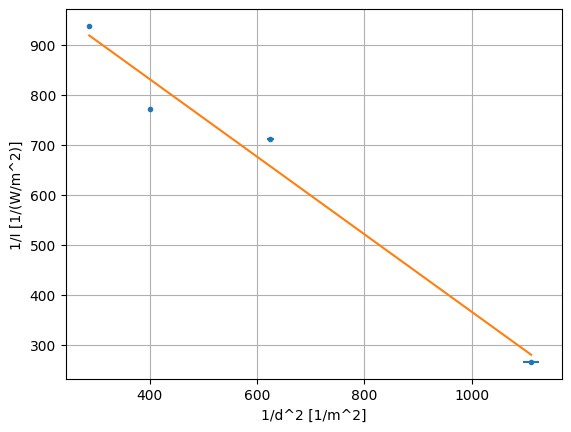

In [33]:
d = np.array([2.95, 2.5, 2, 1.5]) * 1e-2  # ±1e-4, metres
d_err = 1e-4  # Uncertainty in d for 'd'

max1 = np.mean(
    np.diff(np.array([3.3, 4.9, 6.4, 8.1, 9.9, 11.3, 13.1]) * 1e-2)
)  # ±2e-2,
max2 = np.mean(np.diff(np.array([1.5, 3, 4.7, 6.9]) * 1e-2))
max3 = np.mean(np.diff(np.array([3.4, 5.3, 7.2, 9.1, 10.9]) * 1e-2))
max4 = np.mean(np.diff(np.array([1.8, 4.9, 8, 11]) * 1e-2))

data_raw_err = 2e-2  # Uncertainty in the raw max values
data = np.array([max1, max2, max3, max4]) * 2
data_err = data_raw_err * 2  # Propagated uncertainty for 'data'

x_values = 1 / ((2 * d) ** 2)
y_values = 1 / (data**2)

# Calculate xerror using error propagation for x = 1/(4d^2)
xerr_values = np.abs(-1 / (2 * d**3)) * d_err

regress = linregress(x_values, y_values)
slope = regress.slope
intercept = regress.intercept
stderr = regress.stderr
intercept_stderr = regress.intercept_stderr

plt.style.use("default")

print(slope, intercept, stderr)

print(data)
plt.figure()
plt.errorbar(x_values, y_values, xerr=xerr_values, yerr=stderr, fmt=".")
plt.plot(x_values, slope * x_values + intercept)
plt.xlabel("1/d^2 [1/m^2]")
plt.ylabel("1/I [1/(W/m^2)]")
plt.grid()
lam_g = 1 / np.sqrt(intercept)
lam_g_err = 0.5 * intercept ** (-1.5) * intercept_stderr
print("lambda_g =", lam_g * 1e2, "±", lam_g_err * 1e2, "cm")

In [34]:
lam = 2.8 / 100
L = 15.2 / 100
d_circular = (2 * L / np.sqrt(8 * L / lam - 1)) * 100
print(f"{d_circular=}")

d_linear = (L / np.sqrt(4 * L / lam - 1)) * 100
print(f"{d_linear=}")

d_circular=np.float64(4.667070689581294)
d_linear=np.float64(3.3397088454555126)


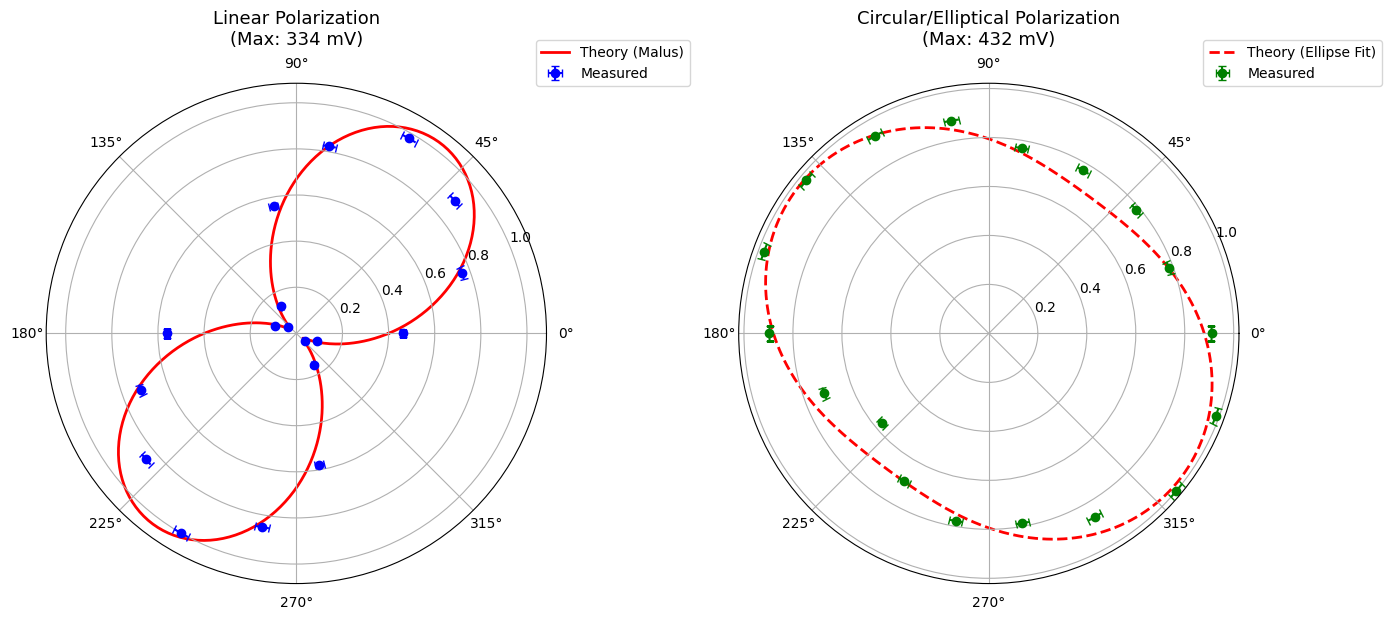

Average: 361.611111, std: 49.341372
R^2 (Linear): 0.9633
R^2 (Circular): 0.7951


In [35]:
q = np.array(
    [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340]
)  # ±2, angels
q = np.radians(q)
### LINEAR ###
linear_intensities = np.array(
    (155, 255, 299, 326, 275, 187, 45, 15, 33, 188, 240, 284, 334, 285, 193, 52, 16, 32)
)
circular_intensities = np.array(
    (
        393,
        338,
        339,
        332,
        332,
        381,
        402,
        420,
        422,
        387,
        309,
        246,
        300,
        336,
        340,
        374,
        432,
        426,
    )
)

# Errors
theta_err_deg = 2.0
theta_err_rad = np.radians(theta_err_deg)
intensity_err_mv = 5.0


def normalize_and_err(data, abs_err):
    max_val = np.max(data)
    norm = data / max_val
    # Scale error: err_norm = err_abs / max_val
    err_norm = np.full_like(data, abs_err / max_val)
    return norm, err_norm, max_val


def malus_law(theta, phase, offset):
    return np.cos(theta - phase) ** 2 + offset


def ellipse_model(theta, I_maj, I_min, angle_offset):
    return (
        I_maj * np.cos(theta - angle_offset) ** 2
        + I_min * np.sin(theta - angle_offset) ** 2
    )


from scipy.optimize import curve_fit

# Fit Linear
popt_lin, _ = curve_fit(malus_law, q_rad, norm_lin, p0=[1.0, 0])

# Fit Circular
popt_circ, _ = curve_fit(ellipse_model, q_rad, norm_circ, p0=[1.0, 0.5, 0])

theta_smooth = np.linspace(0, 2 * np.pi, 500)
curve_lin = malus_law(theta_smooth, *popt_lin)
curve_circ = ellipse_model(theta_smooth, *popt_circ)

fig = plt.figure(figsize=(14, 7))

# --- Graph 1: Linear ---
ax1 = fig.add_subplot(121, projection="polar")
ax1.errorbar(
    q_rad,
    norm_lin,
    xerr=theta_err_rad,
    yerr=err_lin,
    fmt="o",
    capsize=3,
    label="Measured",
    color="blue",
    zorder=2,
)
ax1.plot(theta_smooth, curve_lin, "r-", linewidth=2, label="Theory (Malus)", zorder=1)
ax1.set_title(f"Linear Polarization\n(Max: {max_lin} mV)", va="bottom", fontsize=13)
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

# --- Graph 2: Circular ---
ax2 = fig.add_subplot(122, projection="polar")
ax2.errorbar(
    q_rad,
    norm_circ,
    xerr=theta_err_rad,
    yerr=err_circ,
    fmt="o",
    capsize=3,
    label="Measured",
    color="green",
    zorder=2,
)
ax2.plot(
    theta_smooth, curve_circ, "r--", linewidth=2, label="Theory (Ellipse Fit)", zorder=1
)
ax2.set_title(
    f"Circular/Elliptical Polarization\n(Max: {max_circ} mV)", va="bottom", fontsize=13
)
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

print(
    f"Average: {np.mean(circular_intensities):3f}, std: {np.std(circular_intensities):3f}"
)

y_pred_lin = malus_law(q_rad, *popt_lin)
y_pred_circ = ellipse_model(q_rad, *popt_circ)

# 2. Calculate R^2 using sklearn
r2_lin = r2_score(norm_lin, y_pred_lin)
r2_circ = r2_score(norm_circ, y_pred_circ)

print(f"R^2 (Linear): {r2_lin:.4f}")
print(f"R^2 (Circular): {r2_circ:.4f}")

### Day 2. Building interferometers.

--- Fit Results ---
Amplitude: 287.95 mV
Calculated Wavelength (Lambda): 2.6143 cm
Wavelength Error: ±0.0084 cm


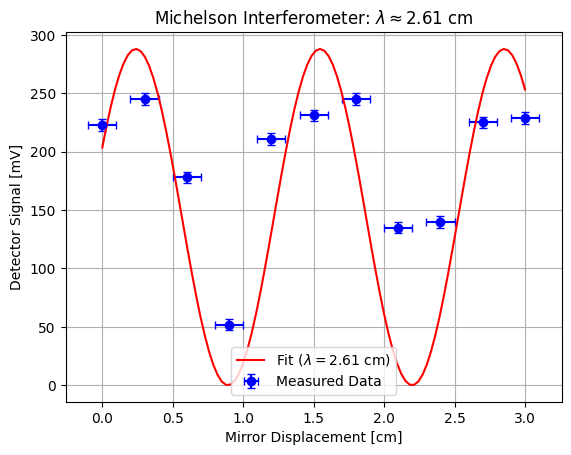

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

plt.style.use("default")

# --- Data Input ---
# Assuming raw distance data is in cm (based on 20.3, 20.6 steps)
x0 = 20  # initial distance offset [cm]
dists_raw = np.array([20, 20.3, 20.6, 20.9, 21.2, 21.5, 21.8, 22.1, 22.4, 22.7, 23])
dists_max = dists_raw - x0  # Distance relative to start [cm]

# Voltage in mV
V_max = np.array([223, 245, 178, 52, 211, 231, 245, 135, 140, 225, 229])

# --- Error Definitions ---
# x_err: 1mm = 0.1 cm
x_err = 0.1
# y_err: 5mV
y_err = 5.0


# --- Model ---
# I = A * sin^2(2*pi*k*x + phase)
# For Michelson, period is Lambda/2.
# sin^2(B*x) has period pi/B.
# Here B = 2*pi*k. Period = pi / (2*pi*k) = 1 / (2k).
# So 1/(2k) = Lambda/2 => Lambda = 1/k.
def wave(x, A, k, phase):
    return A * (np.sin(x * k * 2 * np.pi + phase)) ** 2


# --- Fitting ---
# Initial guess (p0):
# A = 250 (approx max voltage)
# k = 1/2.8 (approx 1/Lambda)
# phase = 0.2 (guess)
p0 = [250, 1 / 2.8, 0.2]

parameters, covariance = scipy.optimize.curve_fit(
    wave, dists_max, V_max, p0=p0, sigma=np.full_like(V_max, y_err), absolute_sigma=True
)

# Extract fit errors (sqrt of diagonal elements of covariance matrix)
perr = np.sqrt(np.diag(covariance))

fit_A = parameters[0]
fit_k = parameters[1]
fit_lambda = 1 / fit_k
fit_lambda_err = perr[1] / (fit_k**2)  # Error propagation for 1/k

print("--- Fit Results ---")
print(f"Amplitude: {fit_A:.2f} mV")
print(f"Calculated Wavelength (Lambda): {fit_lambda:.4f} cm")
print(f"Wavelength Error: ±{fit_lambda_err:.4f} cm")

# --- Plotting ---

# Plot Data with Error Bars
plt.errorbar(
    dists_max, V_max, xerr=x_err, yerr=y_err, fmt="bo", label="Measured Data", capsize=3
)

# Plot Fit Curve
lin = np.linspace(0, dists_max.max(), 100)
plt.plot(
    lin, wave(lin, *parameters), "r-", label=f"Fit ($\\lambda={fit_lambda:.2f}$ cm)"
)

plt.xlabel("Mirror Displacement [cm]")
plt.ylabel("Detector Signal [mV]")
plt.title(f"Michelson Interferometer: $\\lambda \\approx {fit_lambda:.2f}$ cm")
plt.legend()
plt.grid(True)
plt.show()

**Figure .** Michelson interferometer. Voltage vs. distance.

Peak 1: 41.85 cm
Peak 3: 44.8 cm
Wavelength measured: 2.95 ± 0.14 cm


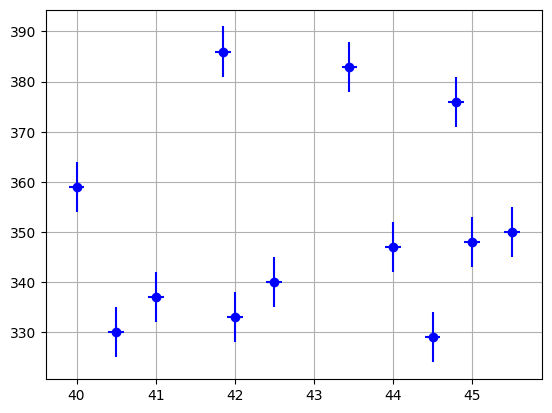

In [37]:
# Fabry-Perot interferometer
mirror_1_d1 = 40  # ±1e-3 m
# mirror_1_d2 = 1  # ±1e-3 m
mirror_2 = 51.1  # ±1e-3 m

d = np.array((40, 40.5, 41, 41.85, 42, 42.5, 44, 44.5, 45, 45.5, 44.8, 43.45))
intensities = np.array((359, 330, 337, 386, 333, 340, 347, 329, 348, 350, 376, 383))
plt.style.use("default")

plt.errorbar(d, intensities, xerr=0.1, yerr=5, fmt="bo", label="meas")
plt.grid()
"""
d11 = mirror_1_d1 - mirror_2
d21 = mirror_1_d2 - mirror_2
"""
max1 = 41.85
max3 = 44.8
max_err = 0.1

lambda_meas = max3 - max1
lambda_err = np.sqrt(max_err**2 + max_err**2)


print(f"Peak 1: {max1} cm")
print(f"Peak 3: {max3} cm")
print(f"Wavelength measured: {lambda_meas:.2f} ± {lambda_err:.2f} cm")

plt.show()

In [38]:
from collections.abc import Callable, Iterable
from pathlib import Path

import autograd.numpy as np
import scipy
from autograd import grad


def propagate_error(
    func: Callable, values: Iterable[float], errors: Iterable[float]
) -> float:
    """
    Generic function for error propagation using autograd.

    :param func: A function that takes multiple arguments and returns a scalar value.
                 Must use autograd.numpy operations for automatic differentiation.
    :param values: The values of the input parameters.
    :param errors: The uncertainties/errors of the input parameters.
    :return: The propagated error (uncertainty) in the output.

    Examples:
        >>> # For f(x, y) = x * y
        >>> def multiply(x, y):
        ...     return x * y
        >>> propagate_error(multiply, (3.0, 4.0), (0.1, 0.2))
    """
    # Convert to numpy arrays for easier handling
    values = np.array(values, dtype=float)
    errors = np.array(errors, dtype=float)

    # Compute gradients with respect to each parameter
    gradients = []
    for i in range(len(values)):
        # Create a gradient function for the i-th parameter
        grad_func = grad(lambda *args: func(*args), i)
        # Evaluate the gradient at the given values
        gradient_value = grad_func(*values)
        gradients.append(gradient_value)

    gradients = np.array(gradients)

    # Apply error propagation formula: σₑ² = Σ(∂f/∂xᵢ)² * σᵢ²
    error_squared = np.sum((gradients**2) * (errors**2))

    return np.sqrt(error_squared)


def get_edited_data_path(path: Path, start_index: int) -> Path:
    data = path.read_text()
    for replacement in (
        ("\t\t", ","),
        ("\t", ","),
        ("	count B	count C	count D", ""),
        ("count A", "ticks"),
        ("#", "line"),
        ("time(s)", "time"),
    ):
        data = data.replace(replacement[0], replacement[1])

    header = data.splitlines()[0]
    data = f"{header}\n" + "\n".join(
        line.removesuffix(",") for line in data.splitlines()[start_index:]
    )  # Trim data before sine.

    new_path = path.with_suffix(".csv")
    new_path.write_text(data)

    return new_path


def get_edited_driven_data_path(path: Path, start_index: int = 1) -> Path:
    data = path.read_text()
    for replacement in (
        ("\t\t", ","),
        ("\t", ","),
        (" count C count D", ""),
        ("count A", "ticks_a"),
        ("count B", "ticks_b"),
        ("#", "line"),
        ("time(s)", "time"),
    ):
        data = data.replace(replacement[0], replacement[1])

    header = data.splitlines()[0]
    data = f"{header}\n" + "\n".join(
        line.removesuffix(",") for line in data.splitlines()[start_index:]
    )  # Trim data before sine.

    new_path = path.with_suffix(".csv")
    new_path.write_text(data)

    return new_path


def get_amplitude(ticks):
    peak_indices, _ = scipy.signal.find_peaks(ticks)
    peaks = ticks[peak_indices]
    peaks_err = []
    radius = 50
    for i in range(len(peak_indices)):
        if i == 0:
            peaks_err.append(
                (
                    max(ticks[peak_indices[i] : peak_indices[i] + radius])
                    - min(ticks[peak_indices[i] : peak_indices[i] + radius])
                )
                / 2
            )
        else:
            peaks_err.append(
                (
                    max(ticks[peak_indices[i] - radius : peak_indices[i] + radius])
                    - min(ticks[peak_indices[i] - radius : peak_indices[i] + radius])
                )
                / 2
            )
    peaks_err = np.array(peaks_err)
    return np.mean(peaks), np.sqrt(sum(peaks_err**2)) / len(peaks_err)

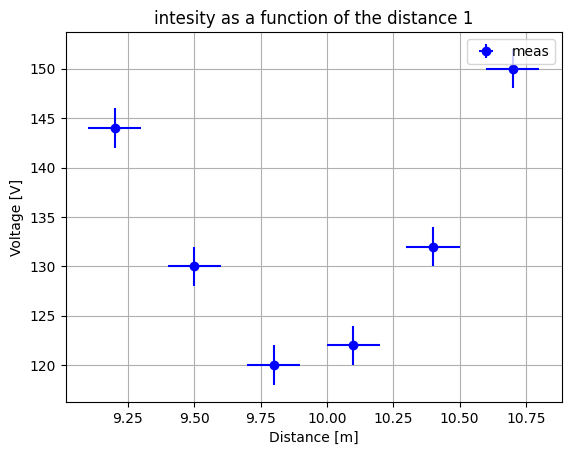

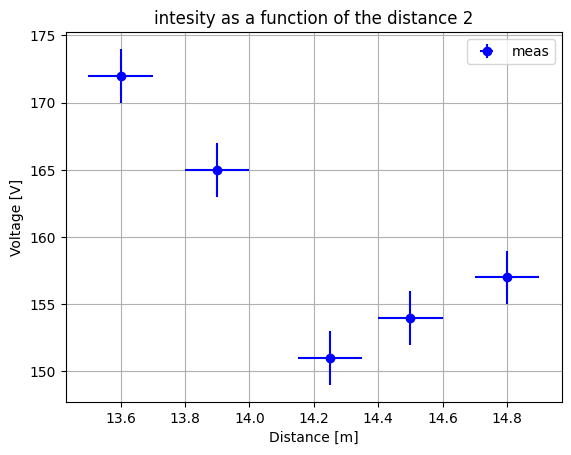

Wavelength measured with Loyd mirror is 2.113 ± 0.342 cm


In [39]:
##%% Loyd Second meas
AC = 0.86  # meter
h_3 = 0.1415
h0 = 1.5
h1 = (9.8 - h0) * 1e-2
h2 = (14.25 - h0) * 1e-2
values_around_min1_dis = np.array([9.2, 9.5, 9.8, 10.1, 10.4, 10.7])  # +-0.005 meters
values_around_min1_int = np.array([144, 130, 120, 122, 132, 150])  # Volts
values_around_min2_dis = np.array([13.6, 13.9, 14.25, 14.5, 14.8])
values_around_min2_int = np.array([172, 165, 151, 154, 157])
plt.errorbar(
    values_around_min1_dis,
    values_around_min1_int,
    xerr=0.1,
    yerr=2,
    fmt="bo",
    label="meas",
)
delta = h2 - h1

plt.xlabel("Distance [m]")
plt.ylabel("Voltage [V]")
plt.title(label="intesity as a function of the distance 1")
plt.legend()
plt.grid()
plt.show()
plt.errorbar(
    values_around_min2_dis,
    values_around_min2_int,
    xerr=0.1,
    yerr=2,
    fmt="bo",
    label="meas",
)
plt.xlabel("Distance [m]")
plt.ylabel("Voltage [V]")
plt.title(label="intesity as a function of the distance 2")
plt.legend()
plt.grid()
plt.show()


def lambda_func(h1, h2, AC):
    return (4 * h2**2 + AC**2) ** 0.5 - (4 * h1**2 + AC**2) ** 0.5


lambda_L3 = ((4 * h2**2 + AC**2) ** 0.5 - (4 * h1**2 + AC**2) ** 0.5) * 1e2
lambda_L3_err = propagate_error(lambda_func, (h1, h2, AC), (5e-3, 5e-3, 1e-3)) * 1e2

"""
AB_3 = (((AC / 2) ** 2) + (h_3 ** 2)) ** 0.5
lambda_L3 = ((AC - 2 * AB_3) * 0.5) * -(10 ** 2)
"""
print(
    f"Wavelength measured with Loyd mirror is {lambda_L3:.3f} ± {lambda_L3_err:.3f} cm"
)

# Summary
## Question 1
Values derived from the three interferometers:
| Method | Wavelength $\lambda$ [cm] |
| :--- | :--- |
| **Michelson Interferometer** | $2.6143 \pm 0.0084$ |
| **Fabry-Perot Interferometer** | $2.95 \pm 0.14$ |
| **Lloyd's Mirror** | $2.113 \pm 0.342$ |

## Question 2
With Loyd we got the least accurate result, With Michelson we got the least uncertain result, but the range doesn't include the given value of 2.8 cm. Fabry-Perot result includes the given value and has moderate uncertainty. Michelson is the best method because it has the smallest uncertainty.

## Question 3
The most accurate method to measure 600nm waves is the Michelson interferometer, because it has the least uncertainty which is important when measuring short wavelengths. We do need to find the systematic error in this method that reduced the accuracy of the measurement. Fabry-Perot is not suitable for 600nm because it relies on many reflections. The mirrors are probably tilted a bit but this doesn't matter for large wavelengths. For 600nm though, the beam will walk off after a few bounces and we won't get the desired interference pattern.
In Lloyd, we can move the mirror a large distance and just count the amount of fringes that pass by. There is a linear relation between them, so there is no problem to move an eye-discernible distance (we'd just get more fringes). However, the path length difference in Lloyd isn't linear ($\sqrt{x^2 + h^2}$), so there is no easy way to move a large distance, and then find the amount of fringes (they don't pass at a constant rate). Additionally, Lloyd's mirror requires the surface to be smooth relative to the wavelength. Not-perfectly-smooth mirrors work for radio wavelengths, but would be impractical for 600nm waves.